In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20&%20T/Data%20Science%20Job%20Salary%20dataset.zip"
df = pd.read_csv(url, compression='zip')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (1171, 7)

Columns: ['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location', 'salary_currency', 'salary']

Data types:
 Unnamed: 0          int64
job_title             str
job_type              str
experience_level      str
location              str
salary_currency       str
salary              int64
dtype: object


# Daily Challenge — Data Handling and Analysis: Data Science Job Salaries

**Dataset:** Data Science Job Salary dataset (1,171 job postings)

## 1. Data Loading and Cleaning

In [2]:
df = df.drop('Unnamed: 0', axis=1)

print("Missing values:\n", df.isnull().sum())
print("\nUnique experience levels:", df['experience_level'].unique())
print("\nUnique salary currencies:", df['salary_currency'].unique())
print("\nSalary stats:\n", df['salary'].describe())

Missing values:
 job_title           0
job_type            0
experience_level    0
location            0
salary_currency     0
salary              0
dtype: int64

Unique experience levels: <StringArray>
['Senior', 'Entry', 'Mid', 'Executive']
Length: 4, dtype: str

Unique salary currencies: <StringArray>
['USD', 'EUR', 'GBP']
Length: 3, dtype: str

Salary stats:
 count      1171.000000
mean      64836.037575
std       32551.767046
min       30000.000000
25%       45000.000000
50%       63000.000000
75%       68000.000000
max      228000.000000
Name: salary, dtype: float64


In [3]:
print("Currency breakdown:")
print(df['salary_currency'].value_counts())

print("\nAverage salary by currency (before any conversion):")
print(df.groupby('salary_currency')['salary'].mean())

Currency breakdown:
salary_currency
USD    1157
EUR       9
GBP       5
Name: count, dtype: int64

Average salary by currency (before any conversion):
salary_currency
EUR    47222.222222
GBP    50400.000000
USD    65035.436474
Name: salary, dtype: float64


In [4]:
exchange_rates = {'USD': 1.0, 'EUR': 1.08, 'GBP': 1.27}  # approximate rates for illustration

df['salary_usd'] = df.apply(lambda row: row['salary'] * exchange_rates[row['salary_currency']], axis=1)

print("Before conversion - avg by currency:")
print(df.groupby('salary_currency')['salary'].mean())
print("\nAfter conversion to USD - avg by currency:")
print(df.groupby('salary_currency')['salary_usd'].mean())

Before conversion - avg by currency:
salary_currency
EUR    47222.222222
GBP    50400.000000
USD    65035.436474
Name: salary, dtype: float64

After conversion to USD - avg by currency:
salary_currency
EUR    51000.000000
GBP    64008.000000
USD    65035.436474
Name: salary_usd, dtype: float64


Salaries were recorded in 3 currencies (USD 98.8%, EUR 0.8%, GBP 0.4%). Since USD dominates, EUR/GBP rows were converted using approximate exchange rates (EUR: 1.08, GBP: 1.27) to create a `salary_usd` column for fair comparison — this is a reasonable approximation for a small number of rows, though real historical exchange rates for the exact posting dates would be more precise if this were a production analysis.

## 2. Min-Max Normalization of Salary

In [6]:
scaler = MinMaxScaler()
df['salary_normalized'] = scaler.fit_transform(df[['salary_usd']])

print(df[['salary_usd', 'salary_normalized']].describe())
print("\nSample rows:")
print(df[['job_title', 'salary_usd', 'salary_normalized']].head(10))

          salary_usd  salary_normalized
count    1171.000000        1171.000000
mean    64923.176772           0.176380
std     32530.756747           0.164297
min     30000.000000           0.000000
25%     45000.000000           0.075758
50%     63000.000000           0.166667
75%     68000.000000           0.191919
max    228000.000000           1.000000

Sample rows:
        job_title  salary_usd  salary_normalized
0  Data scientist    149000.0           0.601010
1  Data scientist    120000.0           0.454545
2  Data scientist     68000.0           0.191919
3  Data scientist    120000.0           0.454545
4  Data scientist    149000.0           0.601010
5  Data scientist     68000.0           0.191919
6  Data scientist     69000.0           0.196970
7  Data scientist     68000.0           0.191919
8  Data scientist    140000.0           0.555556
9  Data scientist     68000.0           0.191919


Min-Max normalization successfully scaled `salary_usd` into a clean 0-1 range (min $30,000 → 0.000, max $228,000 → 1.000). The mean normalized value (0.176) being well below the range's midpoint (0.5) confirms the salary distribution is right-skewed — most postings cluster toward the lower end of the pay scale, with a smaller number of high-paying roles pulling the maximum far above what's typical.

## 3. Dimensionality Reduction with PCA

In [7]:
categorical_cols = ['job_type', 'experience_level', 'location']
df_encoded = pd.get_dummies(df[categorical_cols], columns=categorical_cols)

print("Shape before encoding:", df[categorical_cols].shape)
print("Shape after one-hot encoding:", df_encoded.shape)

pca_input = pd.concat([df_encoded, df[['salary_normalized']]], axis=1)
print("\nFinal PCA input shape:", pca_input.shape)

Shape before encoding: (1171, 3)
Shape after one-hot encoding: (1171, 326)

Final PCA input shape: (1171, 327)


One-hot encoding `job_type`, `experience_level`, and `location` expanded 3 columns into 326 — driven primarily by `location` having many unique values. This is a real-world illustration of exactly why dimensionality reduction is needed: our preprocessing step alone created far more columns than we started with, and PCA will help us compress this back down to a manageable, visualizable number of dimensions.

In [8]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_input)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())

df['PC1'] = pca_result[:, 0]
df['PC2'] = pca_result[:, 1]

Explained variance ratio: [0.24185721 0.09082128]
Total variance captured by 2 components: 0.3326784855277851


The 2 principal components capture only 33.3% of the original dataset's variance (24.2% + 9.1%) — a substantial information loss. This reflects the extreme sparsity introduced by one-hot encoding `location` into hundreds of near-unique columns; PCA struggles to find compact "main patterns" when most encoded columns are almost entirely zeros. This is an honest limitation worth reporting: for this dataset, PCA in just 2 dimensions provides a rough visual summary at best, not a faithful compression of the full feature set.

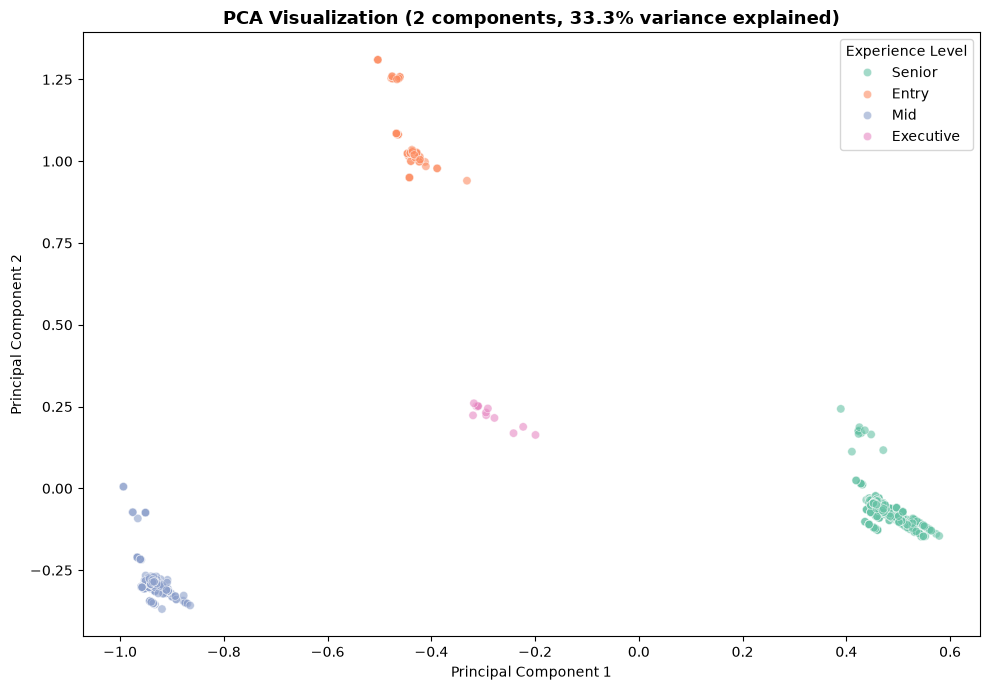

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df['PC1'], y=df['PC2'], hue=df['experience_level'], palette='Set2', alpha=0.6)
plt.title(f'PCA Visualization (2 components, {pca.explained_variance_ratio_.sum()*100:.1f}% variance explained)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Experience Level')
plt.tight_layout()
plt.show()

Despite capturing only 33.3% of total variance, the PCA visualization shows surprisingly clear clustering by experience level — Senior (green) and Mid (blue) form distinct, separated groups, with Entry (orange) and Executive (pink) each forming their own smaller clusters. This shows that a low "variance explained" percentage doesn't necessarily mean the *most meaningful* pattern was lost — here, experience level appears to be one of the dominant signals captured even within the reduced 2D space, even though most of the fine-grained location detail was not preserved.

## 4. Salary Aggregation by Experience Level

                          mean   median           std  count
experience_level                                            
Entry             36111.111111  30000.0  16151.394849    126
Mid               51987.836066  51000.0  20663.098940    305
Senior            75144.085282  68000.0  33529.745405    727
Executive         76076.923077  46000.0  46860.540505     13


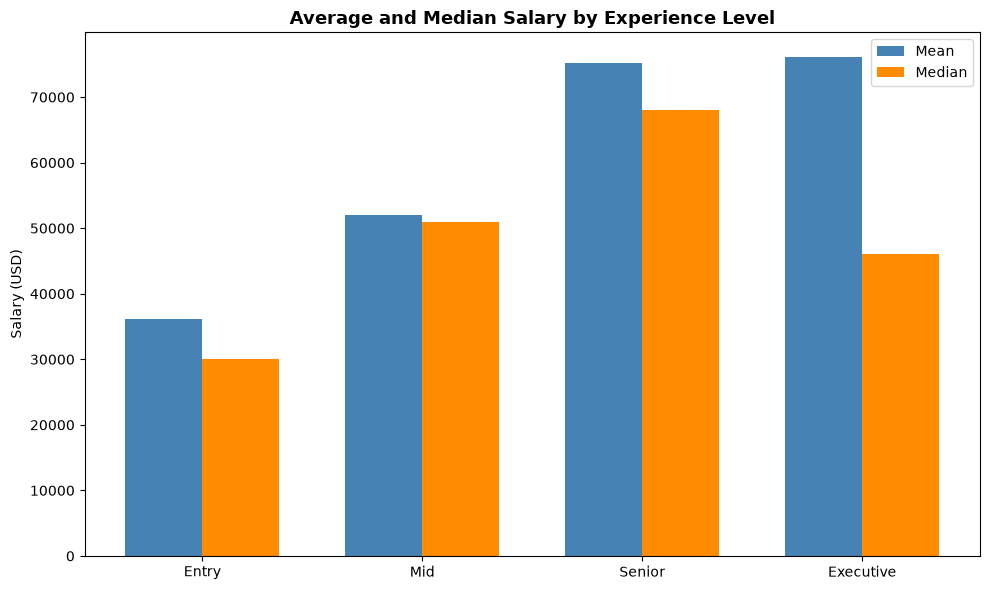

In [10]:
salary_by_experience = df.groupby('experience_level')['salary_usd'].agg(['mean', 'median', 'std', 'count'])
salary_by_experience = salary_by_experience.sort_values('mean')
print(salary_by_experience)

plt.figure(figsize=(10, 6))
x = np.arange(len(salary_by_experience))
width = 0.35

plt.bar(x - width/2, salary_by_experience['mean'], width, label='Mean', color='steelblue')
plt.bar(x + width/2, salary_by_experience['median'], width, label='Median', color='darkorange')

plt.xticks(x, salary_by_experience.index)
plt.ylabel('Salary (USD)')
plt.title('Average and Median Salary by Experience Level', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Mean salary increases steadily from Entry → Mid → Senior → Executive, as expected. However, the median tells a more nuanced story: Executive's median ($46K) is actually LOWER than Senior's median ($68K), despite having the highest mean. This indicates a small number of very high-paid executives are pulling the Executive average up, while most executive-level postings in this dataset pay less than most senior-level ones. Entry and Mid levels show mean and median much closer together, suggesting more consistent pay within those tiers. This reinforces why reporting both mean AND median matters — relying on the mean alone would have hidden a genuinely important pattern in executive-level compensation.

## Summary of Key Findings

1. **Currency mixing was a minor but real data quality issue** — 14 of 1,171 postings (1.2%) were in EUR/GBP, requiring conversion to USD before any salary comparison could be trusted.

2. **Salary distribution is right-skewed** — confirmed by Min-Max normalization: the mean normalized value (0.176) sits well below the range's midpoint, showing most postings cluster toward lower pay with a smaller number of high earners.

3. **One-hot encoding dramatically expanded dimensionality** (3 columns → 326), driven mainly by the `location` column — a real illustration of why dimensionality reduction techniques exist.

4. **PCA captured only 33.3% of total variance in 2 dimensions**, an honest limitation given the sparse, high-cardinality location data — yet still revealed surprisingly clear visual clustering by experience level, showing that a "low variance explained" percentage doesn't necessarily mean the most important pattern was lost.

5. **Mean and median tell different stories at the Executive level** — Executive has the highest mean salary but a LOWER median than Senior, revealing that a small number of very high earners skew the Executive average upward while most executive roles in this dataset are actually paid less than most senior roles.

**Overall conclusion:** this analysis reinforces two recurring lessons from this bootcamp: (1) always check mean alongside median before trusting an average, and (2) preprocessing choices (like one-hot encoding a high-cardinality column) can create new problems that only proper dimensionality reduction techniques help address.